In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import time
import os

/home/apollon/anaconda3/envs/btvts/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:


from ptflops import get_model_complexity_info

# ===== CONFIGURABLE PARAMETERS =====
params = {
    "dataset": "CIFAR10",
    "image_size": 32,
    "patch_size": 4,
    "embed_dim": 256,
    "num_heads": 4,
    "num_layers": 4,
    "num_classes": 10,
    "batch_size": 64,
    "epochs": 100,
    "lr": 3e-4,
    "lambda_ortho": 1e-3,
    "use_svda": True  # ← Toggle this for baseline vs SVDA
}

import random

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False



# Reusable function to measure model complexity
def measure_model_complexity(model, input_res=(3, 32, 32)):
    model = model.cpu()
    model.eval()
    with torch.no_grad():
        macs, params = get_model_complexity_info(
            model, input_res,
            as_strings=False, print_per_layer_stat=False, verbose=False
        )
    return macs, params

def sigma_entropy_loss(sigmas):
    p = (sigmas ** 2)
    p = p / (p.sum(dim=-1, keepdim=True) + 1e-8)
    entropy = -(p * torch.log(p + 1e-8)).sum(dim=-1)  # (L, H)
    return entropy.mean()

set_seed()
if torch.backends.mps.is_available():
    device = torch.device("mps")  # Apple Metal acceleration (M1/M2/M3)
elif torch.cuda.is_available():
    device = torch.device("cuda")  # Typical NVIDIA GPU setup
else:
    device = torch.device("cpu")   # Fallback
print("Using device:", device)


transform = transforms.Compose([
    transforms.RandomCrop(params["image_size"], padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    # transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])
train_data = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_data  = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=params["batch_size"], shuffle=True)
test_loader  = DataLoader(test_data, batch_size=params["batch_size"], shuffle=False)

class PatchEmbedding(nn.Module):
    def __init__(self, in_channels, patch_size, emb_dim, img_size):
        super().__init__()
        self.patch_size = patch_size
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, emb_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)  # (B, D, H', W')
        x = x.flatten(2).transpose(1, 2)  # (B, N, D)
        return x
    
class StandardMultiHeadAttention(nn.Module):
    def __init__(self, dim, num_heads):
        super().__init__()
        self.mha = nn.MultiheadAttention(embed_dim=dim, num_heads=num_heads, batch_first=True)

    def forward(self, x):
        attn_output, _ = self.mha(x, x, x)
        return attn_output
    
class SVDMultiHeadAttention(nn.Module):
    def __init__(self, dim, num_heads, lambda_ortho=0.0):
        super().__init__()
        self.dim = dim
        self.h = num_heads
        self.dk = dim // num_heads
        self.lambda_ortho = lambda_ortho

        self.Wq = nn.Linear(dim, dim)
        self.Wk = nn.Linear(dim, dim)
        self.Wv = nn.Linear(dim, dim)
        self.Wo = nn.Linear(dim, dim)

        self.sigmas = nn.Parameter(torch.empty(self.h, self.dk))
        nn.init.normal_(self.sigmas, mean=1.0, std=0.1)  # Or try mean=0.5 for sharper contrast

        self.attn_weights = None  # store A
        self.angular_alignments = None  # buffer for angular alignment

    def forward(self, x):
        B, N, _ = x.size()
        Q = self.Wq(x).view(B, N, self.h, self.dk).transpose(1, 2)
        K = self.Wk(x).view(B, N, self.h, self.dk).transpose(1, 2)
        V = self.Wv(x).view(B, N, self.h, self.dk).transpose(1, 2)

        Q = F.normalize(Q, dim=-1)
        K = F.normalize(K, dim=-1)
        # Angular alignment: cosine similarity between Q and K (mean per batch, per head)
        cos_sim = torch.sum(Q * K, dim=-1).mean(dim=-1).mean(dim=0)  # (H,)
        self.angular_alignments = cos_sim.detach()

        # Element-wise scaling of Q with sigmas: shape (1, H, 1, Dk)
        weighted_Q = Q * self.sigmas.unsqueeze(0).unsqueeze(2)
        scores = torch.matmul(weighted_Q, K.transpose(-1, -2)) / np.sqrt(self.dk)
        A = F.softmax(scores, dim=-1)

        self.attn_weights = A.detach()  # <=== this line is essential

        Z = torch.matmul(A, V).transpose(1, 2).reshape(B, N, self.dim)
        return self.Wo(Z)

    def orthogonality_loss(self):
        loss_q = ((self.Wq.weight @ self.Wq.weight.T - torch.eye(self.dim).to(self.Wq.weight.device))**2).mean()
        loss_k = ((self.Wk.weight @ self.Wk.weight.T - torch.eye(self.dim).to(self.Wk.weight.device))**2).mean()
        return self.lambda_ortho * (loss_q + loss_k)

class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, use_svda, lambda_ortho):
        super().__init__()
        self.attn = SVDMultiHeadAttention(dim, num_heads, lambda_ortho) if use_svda else StandardMultiHeadAttention(dim, num_heads)
        self.norm1 = nn.LayerNorm(dim)
        self.ff = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Linear(dim * 4, dim)
        )
        self.norm2 = nn.LayerNorm(dim)

    def forward(self, x):
        x = self.norm1(x + self.attn(x))
        x = self.norm2(x + self.ff(x))
        return x

    def get_ortho_loss(self):
        return self.attn.orthogonality_loss() if hasattr(self.attn, "orthogonality_loss") else 0.0


class TransformerClassifier(nn.Module):
    def __init__(self, params):
        super().__init__()
        self.embed = PatchEmbedding(3, params["patch_size"], params["embed_dim"], params["image_size"])
        self.blocks = nn.ModuleList([
            TransformerBlock(params["embed_dim"], params["num_heads"], params["use_svda"], params["lambda_ortho"])
            for _ in range(params["num_layers"])
        ])
        self.cls_token = nn.Parameter(torch.zeros(1, 1, params["embed_dim"]))
        self.norm = nn.LayerNorm(params["embed_dim"])
        self.head = nn.Linear(params["embed_dim"], params["num_classes"])

    def forward(self, x):
        B = x.size(0)
        x = self.embed(x)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        for block in self.blocks:
            x = block(x)
        return self.head(self.norm(x[:, 0]))

    def orthogonality_loss(self):
        return sum([b.get_ortho_loss() for b in self.blocks])
    
def train(model, loader, optimizer, criterion, use_svda):
    model.train()
    total_loss, total_correct = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)

        if use_svda:
            loss += model.orthogonality_loss()
            # Optional: add entropy regularization
            if hasattr(model, "blocks"):
                all_sigmas = torch.stack([b.attn.sigmas for b in model.blocks])  # (L, H, Dk)
                entropy_loss = sigma_entropy_loss(all_sigmas)
                loss += 1e-3 * entropy_loss  # ← You can tune this weight

        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_correct += (logits.argmax(1) == y).sum().item()
    acc = total_correct / len(loader.dataset)
    return total_loss / len(loader), acc

def evaluate(model, loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            correct += (logits.argmax(1) == y).sum().item()
    return correct / len(loader.dataset)

def spectral_entropy(sigmas):
    # sigmas shape: (L, H, Dk)
    p = (sigmas ** 2)
    p = p / (p.sum(dim=-1, keepdim=True) + 1e-8)  # normalize over Dk
    entropy = -(p * torch.log(p + 1e-8)).sum(dim=-1)  # shape: (L, H)
    return entropy  # <-- return tensor, NOT entropy.mean().item()

def effective_rank(entropy_tensor):
    return torch.exp(entropy_tensor).mean().item()

def spectral_sparsity(sigmas, threshold=1e-3):
    mask = (sigmas.abs() < threshold).float()
    return mask.mean().item()

def run_experiment(use_svda_flag):
    print(f"\nTraining {'SVDA' if use_svda_flag else 'Baseline'} Transformer...")
    # Set device to GPU if available, else CPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = TransformerClassifier({**params, "use_svda": use_svda_flag})
    model = model.to(device)  # Move model to the device
    # ----- Model summary logging -----
    from torchinfo import summary
    model_summary = summary(model, input_size=(1, 3, params["image_size"], params["image_size"]), verbose=0)
    summary_filename = "model_summary_svda.txt" if use_svda_flag else "model_summary_baseline.txt"
    with open(summary_filename, "w") as f:
        f.write(str(model_summary))
    # ---------------------------------
    optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"])
    criterion = nn.CrossEntropyLoss()

    train_accs, test_accs = [], []
    entropy_log, rank_log, sparsity_log, time_log = [], [], [], []
    selectivity_log = []  # Log for selectivity index
    robustness_log = []
    angular_log = []  # Log for angular alignment
    epsilon = 1e-2
    # For per-layerwise logging
    if use_svda_flag:
        entropy_layerwise = []
        rank_layerwise = []
        sparsity_layerwise = []
        alignment_layerwise = []
        selectivity_layerwise = []
        robustness_layerwise = []

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total trainable parameters: {total_params:,}")

    # (Optional: print model complexity here if desired)

    best_acc = 0
    epochs_no_improve = 0
    patience = 10
    for epoch in range(params["epochs"]):
        start_time = time.time()

        train_loss, train_acc = train(model, train_loader, optimizer, criterion, use_svda=use_svda_flag)
        test_acc = evaluate(model, test_loader)

        end_time = time.time()
        duration = end_time - start_time
        time_log.append(duration)

        print(f"Epoch {epoch+1:02d} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f} | Time: {duration:.2f}s")

        train_accs.append(train_acc)
        test_accs.append(test_acc)

        # Structural metrics for SVDA
        if use_svda_flag:
            with torch.no_grad():
                all_sigmas = [block.attn.sigmas.detach().cpu() for block in model.blocks]
                all_sigmas = torch.stack(all_sigmas)  # (L, H, Dk)

                ent = spectral_entropy(all_sigmas)    # Tensor
                effr = effective_rank(ent)
                spar = spectral_sparsity(all_sigmas)

                entropy_log.append(ent.mean().item())
                entropy_layerwise.append(ent.numpy())  # (L, H)
                rank_log.append(effr)
                rank_layerwise.append(torch.exp(ent).numpy())  # effective rank per head
                sparsity_log.append(spar)
                sparsity_layerwise.append((all_sigmas.abs() < 1e-3).float().mean(dim=-1).numpy())  # (L, H)

                # Compute selectivity index per layer
                selectivity_per_layer = []
                for block in model.blocks:
                    if hasattr(block.attn, "attn_weights") and block.attn.attn_weights is not None:
                        A = block.attn.attn_weights  # (B, H, N, N)
                        sel = 1 - (A**2).sum(dim=-1) / (A.sum(dim=-1)**2 + 1e-8)
                        selectivity_per_layer.append(sel.mean(dim=(0, 1)).cpu().numpy())  # (H,)
                    else:
                        selectivity_per_layer.append(np.nan * np.ones(params["num_heads"]))
                selectivity_layerwise.append(np.stack(selectivity_per_layer))  # (L, H)
                selectivity_log.append(np.mean(selectivity_layerwise[-1]))

                # Perturbation Robustness per layer
                robustness_per_layer = []
                sample_x, _ = next(iter(test_loader))
                # Move sample_x to the same device as the model
                sample_x = sample_x[:1]
                sample_x = sample_x.to(device)
                delta = torch.randn_like(sample_x) * epsilon
                perturbed_x = torch.clamp(sample_x + delta, 0, 1)
                # Ensure model is on the correct device
                model = model.to(device)
                _ = model(sample_x)
                A_clean_all = [block.attn.attn_weights for block in model.blocks]
                _ = model(perturbed_x)
                A_perturbed_all = [block.attn.attn_weights for block in model.blocks]
                for A_clean, A_perturbed in zip(A_clean_all, A_perturbed_all):
                    delta_A = (A_clean - A_perturbed).norm(p='fro') / A_clean.numel()
                    robustness_per_layer.append(delta_A.item())
                robustness_layerwise.append(robustness_per_layer)
                robustness_log.append(np.mean(robustness_per_layer))

                # Log angular alignment
                attn_block = model.blocks[-1]
                alignment = attn_block.attn.angular_alignments  # (H,)
                angular_log.append(alignment.mean().item())
                alignment_layerwise.append(torch.stack([b.attn.angular_alignments for b in model.blocks]).cpu().numpy())  # (L, H)

        # Early stopping logic
        # if test_acc > best_acc:
        #     best_acc = test_acc
        #     epochs_no_improve = 0
        # else:
        #     epochs_no_improve += 1

        # if epochs_no_improve >= patience:
        #     print(f"Early stopping at epoch {epoch+1}")
        #     break

    # Export logs to disk for reproducibility
    seed_suffix = params.get('seed', 42)
    if use_svda_flag:
        os.makedirs("logs_svda_cifar10", exist_ok=True)
        np.save(f"logs_svda_cifar10/entropy_seed{seed_suffix}.npy", np.array(entropy_log))
        np.save(f"logs_svda_cifar10/effective_rank_seed{seed_suffix}.npy", np.array(rank_log))
        np.save(f"logs_svda_cifar10/sparsity_seed{seed_suffix}.npy", np.array(sparsity_log))
        np.save(f"logs_svda_cifar10/selectivity_seed{seed_suffix}.npy", np.array(selectivity_log))
        np.save(f"logs_svda_cifar10/robustness_seed{seed_suffix}.npy", np.array(robustness_log))
        np.save(f"logs_svda_cifar10/angular_alignment_seed{seed_suffix}.npy", np.array(angular_log))
        np.save(f"logs_svda_cifar10/test_accuracy_seed{seed_suffix}.npy", np.array(test_accs))
        # Save layerwise logs
        np.save(f"logs_svda_cifar10/entropy_layerwise_seed{seed_suffix}.npy", np.array(entropy_layerwise))
        np.save(f"logs_svda_cifar10/rank_layerwise_seed{seed_suffix}.npy", np.array(rank_layerwise))
        np.save(f"logs_svda_cifar10/sparsity_layerwise_seed{seed_suffix}.npy", np.array(sparsity_layerwise))
        np.save(f"logs_svda_cifar10/angular_alignment_layerwise_seed{seed_suffix}.npy", np.array(alignment_layerwise))
        np.save(f"logs_svda_cifar10/selectivity_layerwise_seed{seed_suffix}.npy", np.array(selectivity_layerwise))
        np.save(f"logs_svda_cifar10/robustness_layerwise_seed{seed_suffix}.npy", np.array(robustness_layerwise))
        return model, train_accs, test_accs, entropy_log, rank_log, sparsity_log, time_log, selectivity_log, robustness_log, angular_log
    else:
        os.makedirs("logs_baseline_cifar10", exist_ok=True)
        np.save(f"logs_baseline_cifar10/test_accuracy_seed{seed_suffix}.npy", np.array(test_accs))
        return model, train_accs, test_accs, None, None, None, time_log







Using device: cuda


100%|██████████| 170498071/170498071 [00:08<00:00, 20138575.66it/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


In [ ]:
# train the two competing models
base_model, baseline_train, baseline_test, _, _, _, baseline_time = run_experiment(use_svda_flag=False)
svda_model, svda_train, svda_test, svda_entropy, svda_rank, svda_sparsity, svda_time, svda_selectivity, svda_robustness, svda_angular = run_experiment(use_svda_flag=True)

# Save full experiment results
torch.save({
    "model_state_dict": base_model.state_dict(),
    "train_acc": baseline_train,
    "test_acc": baseline_test,
    "time_log": baseline_time
}, "baseline_results_cifar10.pth")

torch.save({
    "model_state_dict": svda_model.state_dict(),
    "train_acc": svda_train,
    "test_acc": svda_test,
    "entropy": svda_entropy,
    "effective_rank": svda_rank,
    "sparsity": svda_sparsity,
    "time_log": svda_time,
    "selectivity": svda_selectivity,
    "robustness": svda_robustness,
    "angular_alignment": svda_angular
}, "svda_results_cifar10.pth")


<>:61: SyntaxWarning: invalid escape sequence '\S'
<>:125: SyntaxWarning: invalid escape sequence '\S'
<>:156: SyntaxWarning: invalid escape sequence '\S'
<>:61: SyntaxWarning: invalid escape sequence '\S'
<>:125: SyntaxWarning: invalid escape sequence '\S'
<>:156: SyntaxWarning: invalid escape sequence '\S'
/tmp/ipykernel_4046006/3756883150.py:61: SyntaxWarning: invalid escape sequence '\S'
  plt.title("Spectral Entropy of $\Sigma$")
/tmp/ipykernel_4046006/3756883150.py:125: SyntaxWarning: invalid escape sequence '\S'
  plt.title(f"Layer {l} - Per-Head Spectra ($\Sigma$)")
/tmp/ipykernel_4046006/3756883150.py:156: SyntaxWarning: invalid escape sequence '\S'
  plt.title("Learned $\Sigma$ Spectrum (Head 0, Last Layer)")


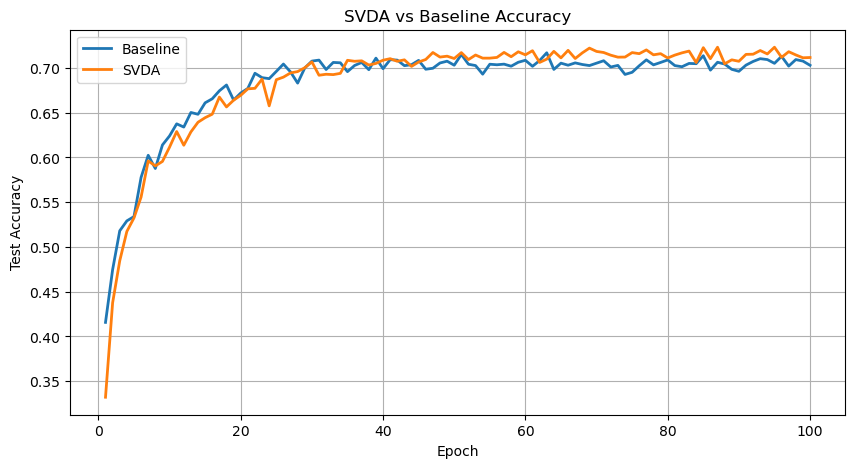

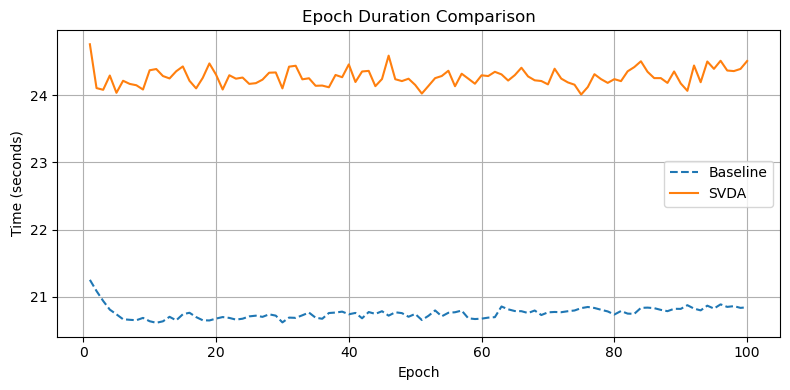

<Figure size 1500x400 with 0 Axes>

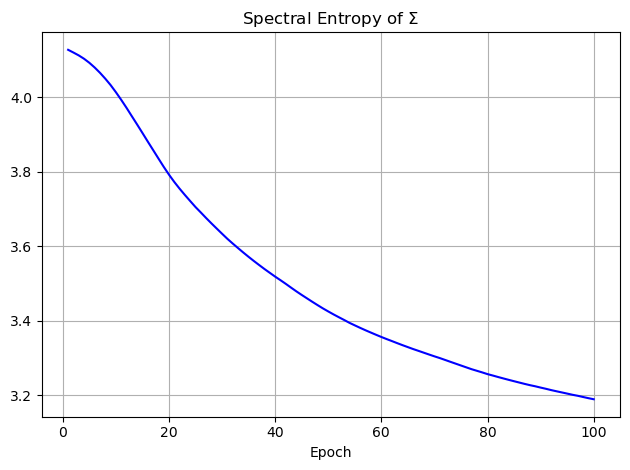

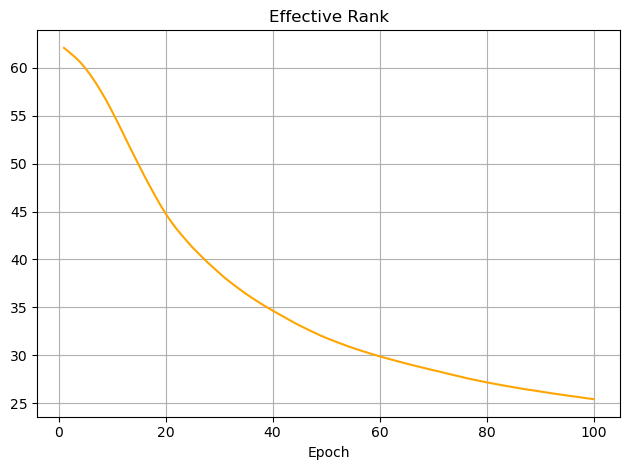

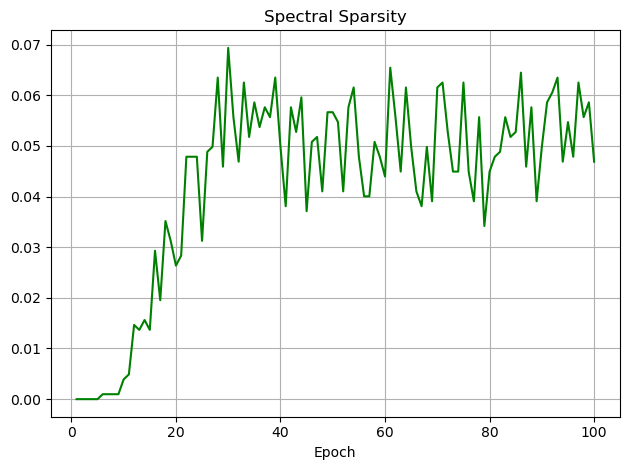

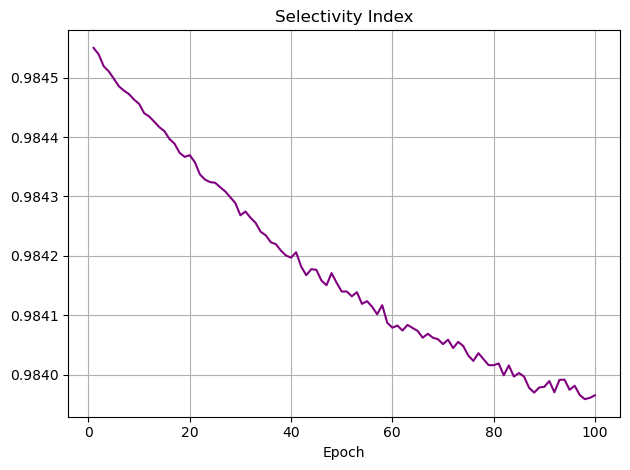

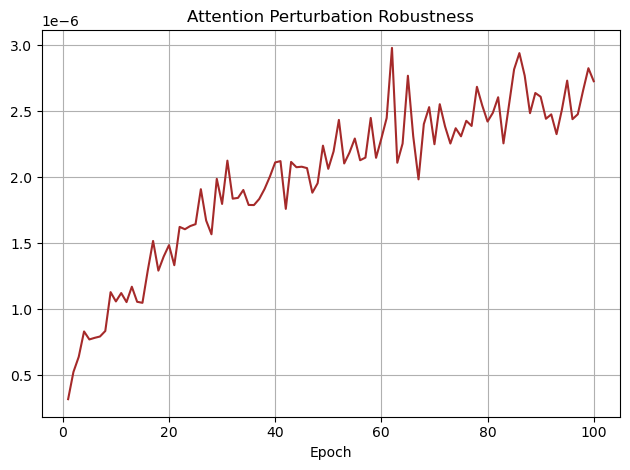

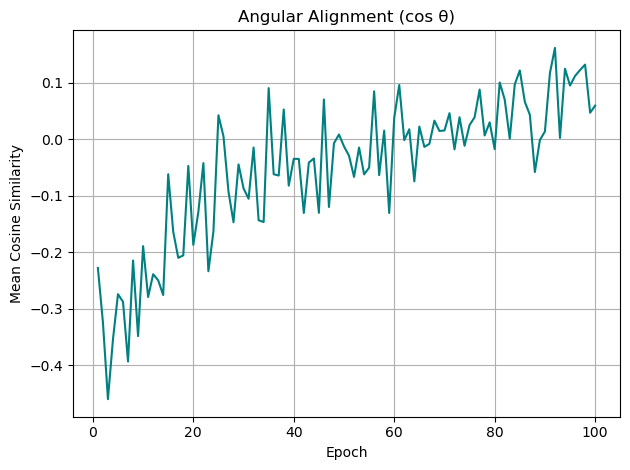

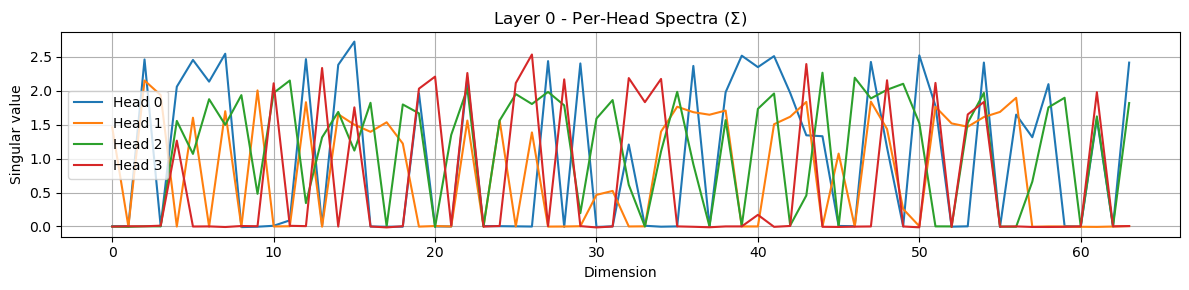

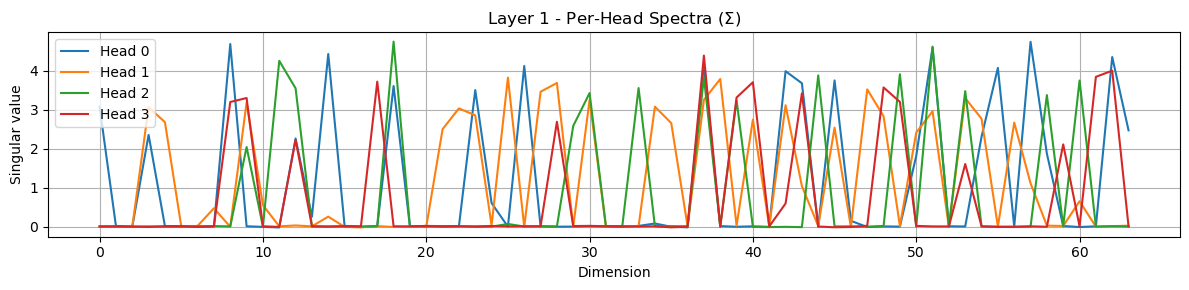

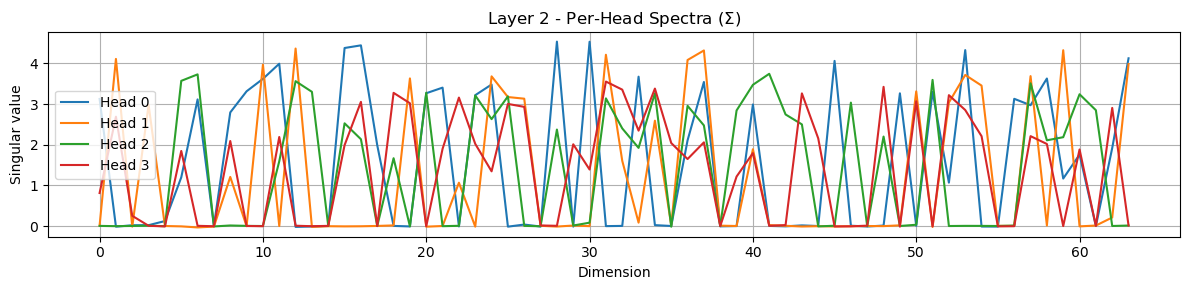

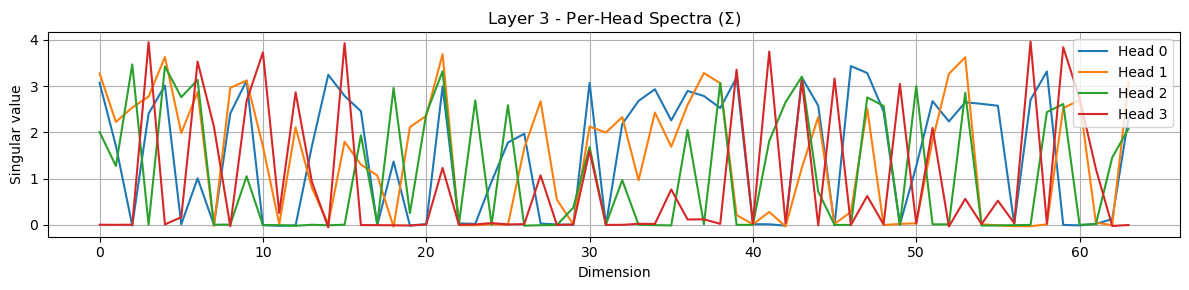

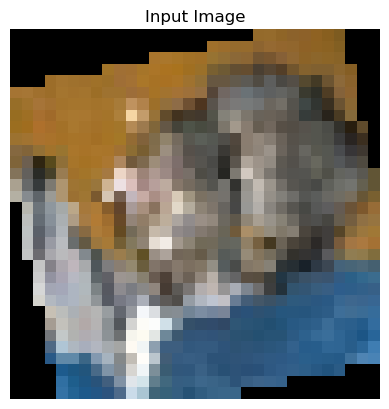

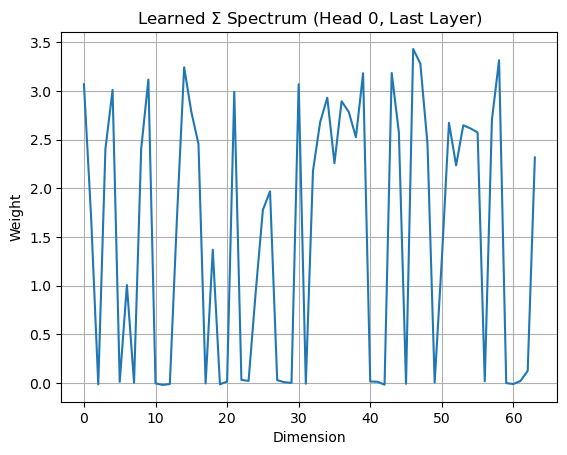

Attention correlation: we use sigma to show latent focus. Direct attention A requires model hook.


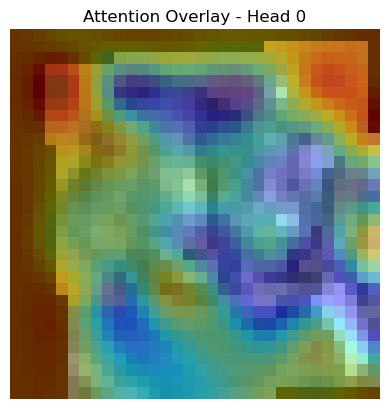

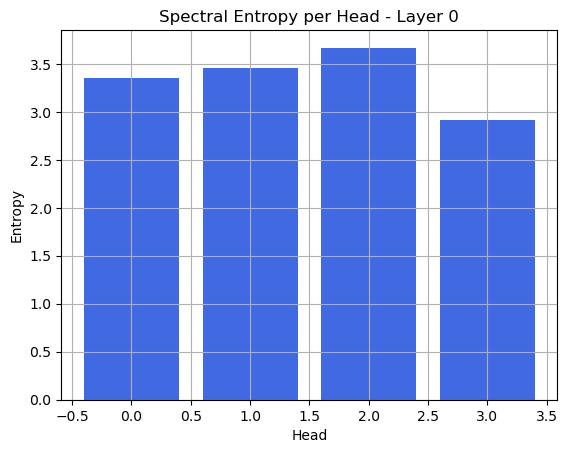

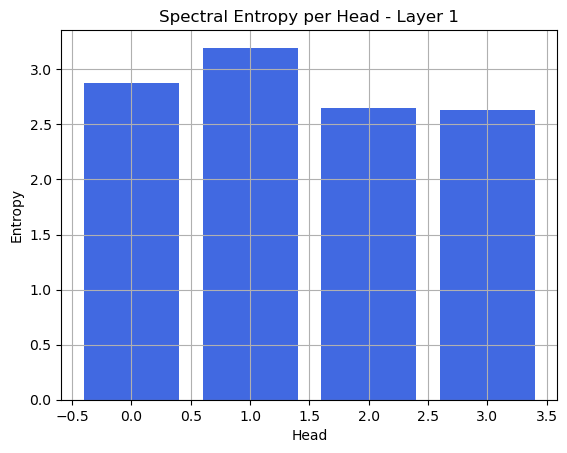

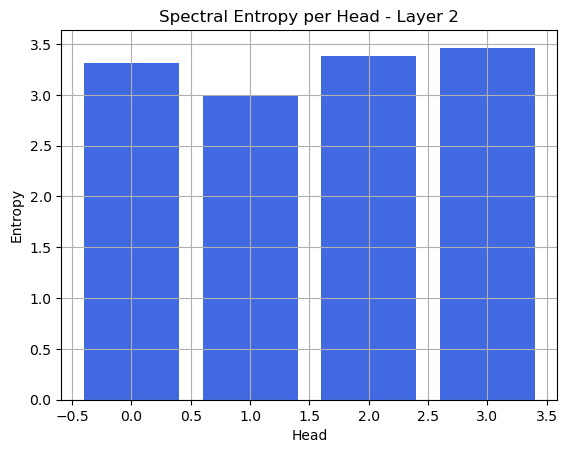

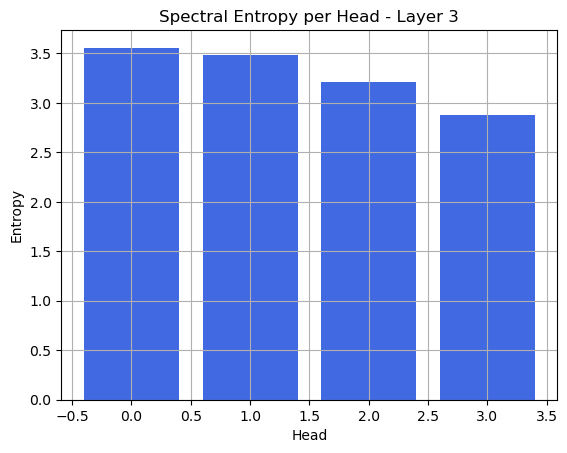

Example Σ (Layer 0, Head 0):
tensor([ 2.6958e-03,  3.6819e-03,  2.4635e+00,  3.7485e-03,  2.0614e+00,
         2.4565e+00,  2.1363e+00,  2.5480e+00, -9.6272e-03, -3.9238e-03,
         9.8596e-03,  9.0093e-02,  2.4682e+00,  7.9291e-03,  2.3839e+00,
         2.7266e+00, -1.1631e-03, -3.8548e-03, -3.2650e-03,  1.9653e+00,
         2.7480e-04, -7.4733e-04,  2.1906e+00,  5.9912e-03,  4.0004e-03,
         1.6032e-03, -1.2838e-03,  2.4392e+00, -6.0710e-03,  2.4049e+00,
        -7.8464e-03,  1.7342e-03,  1.2091e+00,  1.0247e-02, -3.7645e-03,
         8.1190e-04,  2.3681e+00,  6.4037e-04,  1.9796e+00,  2.5193e+00,
         2.3505e+00,  2.5126e+00,  1.9696e+00,  1.3446e+00,  1.3308e+00,
         7.3532e-03,  3.5176e-03,  2.4268e+00,  1.1623e+00,  5.2776e-05,
         2.5240e+00,  1.7781e+00, -3.0512e-03,  1.8378e-03,  2.4179e+00,
        -6.9448e-03,  1.6496e+00,  1.3160e+00,  2.0995e+00,  5.5459e-03,
        -2.9502e-03,  1.5880e+00,  2.7382e-03,  2.4169e+00])
Min: -0.009627163410186768 Max: 2.

In [5]:
#
# Reload full results for plotting
baseline_ckpt = torch.load("baseline_results_cifar10.pth", map_location=device)
svda_ckpt = torch.load("svda_results_cifar10.pth", map_location=device)

base_model = TransformerClassifier({**params, "use_svda": False})
svda_model = TransformerClassifier({**params, "use_svda": True})

base_model.load_state_dict(baseline_ckpt["model_state_dict"])
svda_model.load_state_dict(svda_ckpt["model_state_dict"])

base_model = base_model.to(device)
svda_model = svda_model.to(device)

base_model.eval()
svda_model.eval()

# Restore metrics
baseline_train = baseline_ckpt["train_acc"]
baseline_test = baseline_ckpt["test_acc"]
baseline_time = baseline_ckpt["time_log"]

svda_train = svda_ckpt["train_acc"]
svda_test = svda_ckpt["test_acc"]
svda_entropy = svda_ckpt["entropy"]
svda_rank = svda_ckpt["effective_rank"]
svda_sparsity = svda_ckpt["sparsity"]
svda_time = svda_ckpt["time_log"]
svda_selectivity = svda_ckpt["selectivity"]
svda_robustness = svda_ckpt["robustness"]
svda_angular = svda_ckpt["angular_alignment"]


plt.figure(figsize=(10, 5))
plt.plot(range(1, len(baseline_test) + 1), baseline_test, label="Baseline", linewidth=2)
plt.plot(range(1, len(svda_test) + 1), svda_test, label="SVDA", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("SVDA vs Baseline Accuracy")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(baseline_time) + 1), baseline_time, label="Baseline", linestyle='--')
plt.plot(range(1, len(svda_time) + 1), svda_time, label="SVDA", linestyle='-')
plt.title("Epoch Duration Comparison")
plt.xlabel("Epoch")
plt.ylabel("Time (seconds)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

svda_epochs = list(range(1, len(svda_entropy) + 1))

plt.figure(figsize=(15, 4))

plt.figure()
plt.plot(svda_epochs, svda_entropy, label="Entropy", color="blue")
plt.title("Spectral Entropy of $\Sigma$")
plt.xlabel("Epoch")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(svda_epochs, svda_rank, label="Effective Rank", color="orange")
plt.title("Effective Rank")
plt.xlabel("Epoch")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(svda_epochs, svda_sparsity, label="Sparsity", color="green")
plt.title("Spectral Sparsity")
plt.xlabel("Epoch")
plt.grid(True)
plt.tight_layout()
plt.show()

# Selectivity
plt.figure()
plt.plot(svda_epochs, svda_selectivity, label="Selectivity", color="purple")
plt.title("Selectivity Index")
plt.xlabel("Epoch")
plt.grid(True)
plt.tight_layout()
plt.show()

# Robustness
plt.figure()
plt.plot(svda_epochs, svda_robustness, label="Perturbation Robustness", color="brown")
plt.title("Attention Perturbation Robustness")
plt.xlabel("Epoch")
plt.grid(True)
plt.tight_layout()
plt.show()

# Angular Alignment
plt.figure()
plt.plot(svda_epochs, svda_angular, label="Angular Alignment", color="teal")
plt.title("Angular Alignment (cos θ)")
plt.xlabel("Epoch")
plt.ylabel("Mean Cosine Similarity")
plt.grid(True)
plt.tight_layout()
plt.show()


# Per-Head Spectra Plot
with torch.no_grad():
    last_sigmas = [block.attn.sigmas.detach().cpu() for block in svda_model.blocks]
    last_sigmas = torch.stack(last_sigmas)  # (L, H, Dk)

    num_layers = last_sigmas.shape[0]
    num_heads = last_sigmas.shape[1]
    d_k = last_sigmas.shape[2]

    for l in range(num_layers):
        plt.figure(figsize=(12, 3))
        for h in range(num_heads):
            plt.plot(last_sigmas[l, h], label=f"Head {h}")
        plt.title(f"Layer {l} - Per-Head Spectra ($\Sigma$)")
        plt.xlabel("Dimension")
        plt.ylabel("Singular value")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# Attention Maps + Sigma Focus (Correlation View)
svda_model.eval()
x, y = next(iter(test_loader))
# Set device to GPU if available, else CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x = x[:1]
x = x.to(device)  # Take one image and move to the correct device
svda_model = svda_model.to(device)
with torch.no_grad():
    _ = svda_model(x)  # forward pass to initialize attention

# Show the input image
img_np = x[0].permute(1, 2, 0).cpu().numpy()
plt.imshow(img_np)
plt.title("Input Image")
plt.axis('off')
plt.show()

# Plot attention scores from head 0 of last layer
last_block = svda_model.blocks[-1]
if hasattr(last_block.attn, "sigmas"):
    sigma = last_block.attn.sigmas[0].detach().cpu()  # Head 0
    plt.plot(sigma)
    plt.title("Learned $\Sigma$ Spectrum (Head 0, Last Layer)")
    plt.xlabel("Dimension")
    plt.ylabel("Weight")
    plt.grid(True)
    plt.show()

    # (Optional) approximate attention via QK (can't extract A directly)
    print("Attention correlation: we use sigma to show latent focus. Direct attention A requires model hook.")

# Hook into the model and extract attention after inference
def extract_attention_maps(model, x, layer_idx= -1, head_idx=0):
    model.eval()
    with torch.no_grad():
        _ = model(x)  # trigger forward

    attn_block = model.blocks[layer_idx].attn
    A = attn_block.attn_weights  # shape: (B, H, N, N)
    return A[0, head_idx].cpu()  # return attention from batch[0], head h

# Visualize Attention Overlays on the Input Image
def visualize_attention_overlay(attn_map, image, patch_size, title=""):
    image_np = image.permute(1, 2, 0).cpu().numpy()
    img_size = image_np.shape[0]

    fig, ax = plt.subplots()
    ax.imshow(image_np)
    ax.set_title(title)
    ax.axis('off')

    N = attn_map.shape[-1] - 1  # ignore CLS
    heatmap = attn_map[1:, 0].reshape(int(np.sqrt(N)), int(np.sqrt(N)))  # CLS-to-patches

    heatmap = heatmap.numpy()
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

    from scipy.ndimage import zoom
    heatmap = zoom(heatmap, patch_size)
    ax.imshow(heatmap, cmap='jet', alpha=0.4)

    plt.show()

# visualize attention overlays
def visualize_attention_overlay(attn_map, image, patch_size, title=""):
    image_np = image.permute(1, 2, 0).cpu().numpy()
    img_size = image_np.shape[0]

    fig, ax = plt.subplots()
    ax.imshow(image_np)
    ax.set_title(title)
    ax.axis('off')

    N = attn_map.shape[-1] - 1  # ignore CLS
    heatmap = attn_map[1:, 0].reshape(int(np.sqrt(N)), int(np.sqrt(N)))  # CLS-to-patches

    heatmap = heatmap.numpy()
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

    from scipy.ndimage import zoom
    heatmap = zoom(heatmap, patch_size)
    ax.imshow(heatmap, cmap='jet', alpha=0.4)

    plt.show()

#Color-Code Heads by Spectral Entropy
def headwise_entropy_colorbars(sigmas):
    p = (sigmas ** 2)
    p = p / (p.sum(dim=-1, keepdim=True) + 1e-8)
    entropy = -(p * torch.log(p + 1e-8)).sum(dim=-1)  # shape: (L, H)

    for l in range(entropy.shape[0]):
        plt.bar(np.arange(entropy.shape[1]), entropy[l].numpy(), color='royalblue')
        plt.title(f"Spectral Entropy per Head - Layer {l}")
        plt.xlabel("Head")
        plt.ylabel("Entropy")
        plt.grid(True)
        plt.show()

# end-to-end example

# 1. Take one sample
sample_img, _ = next(iter(test_loader))
sample_img = sample_img[:1].to(device)

# 2. Run model and extract A
attn_map = extract_attention_maps(svda_model, sample_img, layer_idx=-1, head_idx=0)

# 3. Show attention overlay
visualize_attention_overlay(attn_map, sample_img[0], patch_size=params["patch_size"], title="Attention Overlay - Head 0")

# 4. Show entropy per head
with torch.no_grad():
    sigmas_all = torch.stack([b.attn.sigmas.detach().cpu() for b in svda_model.blocks])
    headwise_entropy_colorbars(sigmas_all)

print("Example Σ (Layer 0, Head 0):")
print(last_sigmas[0, 0])
print("Min:", last_sigmas[0, 0].min().item(), "Max:", last_sigmas[0, 0].max().item())


In [7]:
import torch
import time
from ptflops import get_model_complexity_info

def print_training_step_stats(model, input_res=(3, 32, 32), device='cuda' if torch.cuda.is_available() else 'cpu'):
    model = model.to(device)
    model.train()

    dummy_input = torch.randn((64, *input_res)).to(device)  # Batch of 64
    dummy_target = torch.randint(0, 10, (64,)).to(device)

    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

    forward_times, backward_times = [], []

    for _ in range(10):  # Run 10 steps to get stable average
        optimizer.zero_grad()

        # Forward pass timing
        start_fwd = time.time()
        output = model(dummy_input)
        loss = criterion(output, dummy_target)
        if device == 'cuda':
            torch.cuda.synchronize()
        end_fwd = time.time()
        forward_times.append(end_fwd - start_fwd)

        # Backward pass timing
        start_bwd = time.time()
        loss.backward()
        optimizer.step()
        if device == 'cuda':
            torch.cuda.synchronize()
        end_bwd = time.time()
        backward_times.append(end_bwd - start_bwd)

    print(f"Model: {model.__class__.__name__}")
    print(f"  Avg forward time per batch: {1000 * sum(forward_times)/len(forward_times):.2f} ms")
    print(f"  Avg backward+update time per batch: {1000 * sum(backward_times)/len(backward_times):.2f} ms")

    # MACs estimate (not fully accurate for training, but indicative)
    with torch.no_grad():
        macs, params = get_model_complexity_info(
            model, input_res, as_strings=True,
            print_per_layer_stat=False, verbose=False
        )
    print(f"  MACs (inference-only est.): {macs}")
    print(f"  Parameters: {params}\n")

In [8]:
print_training_step_stats(base_model)
print_training_step_stats(svda_model)

Model: TransformerClassifier
  Avg forward time per batch: 7.63 ms
  Avg backward+update time per batch: 12.02 ms
  MACs (inference-only est.): 215.33 MMac
  Parameters: 3.17 M

Model: TransformerClassifier
  Avg forward time per batch: 3.81 ms
  Avg backward+update time per batch: 45.34 ms
  MACs (inference-only est.): 215.26 MMac
  Parameters: 3.18 M

